# 03 — Paper-Ready Tables & Figures

Reads the CSV outputs produced by notebook 02 (in `results/table/`) and
renders publication-quality artefacts:

- **LaTeX tables** (`results/table/*.tex`) — drop straight into the
  Overleaf `sections/` (Table 2 convergent validity, cut-off table).
- **Figures** (`results/figures/*.png`, `*.pdf`) — correlation heatmap,
  grade-distribution bar chart, hard-coded vs quartile cut-off comparison.

Run notebooks 01 and 02 first.


Wrote table_convergent_validity.tex

\begin{table}[t]
  \centering
  \caption{Pairwise agreement across three ESG raters (Dow~30, direction-aligned).}
  \label{tab:corr}
  \begin{tabular}{@{}lS[table-format=-1.3]S[table-format=-1.3]@{}}
    \toprule
    Rater pair & {Pearson $r$} & {Spearman $\rho$} \\
    \midrule
    S\&P vs Sustainalytics & -0.163 & 0.021 \\
    S\&P vs MSCI & 0.251 & 0.266 \\
    Sustainalytics vs MSCI & 0.285 & 0.295 \\
    \midrule
    MEAN & 0.124 & 0.194 \\
    \bottomrule
  \end{tabular}
\end{table}


Wrote table_cutoff.tex

\begin{table}[t]
  \centering
  \caption{Hard-coded versus distribution-based grade cut-offs
           (broad dataset, $n=722$).}
  \label{tab:cutoff}
  \begin{tabular}{@{}lccc@{}}
    \toprule
    Cut-off scheme & Lower & Middle & Upper \\
    \midrule
    Hard-coded (observed) & 750 & 900 & 1200 \\
    Distribution-based (quartiles) & 763 & 1046 & 1144 \\
    \bottomrule
  \end{tabular}
\end{table}

Wrote table_kappa.tex

\begin{table}[

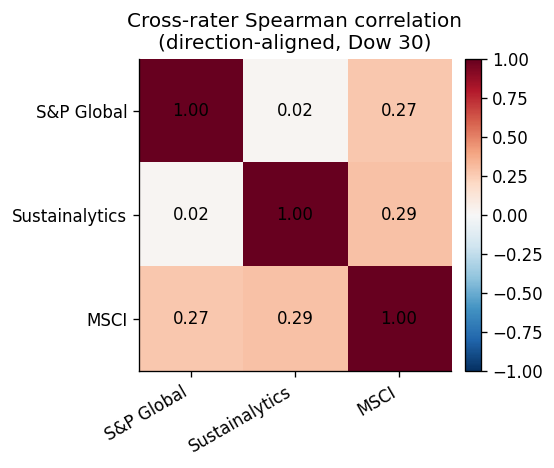

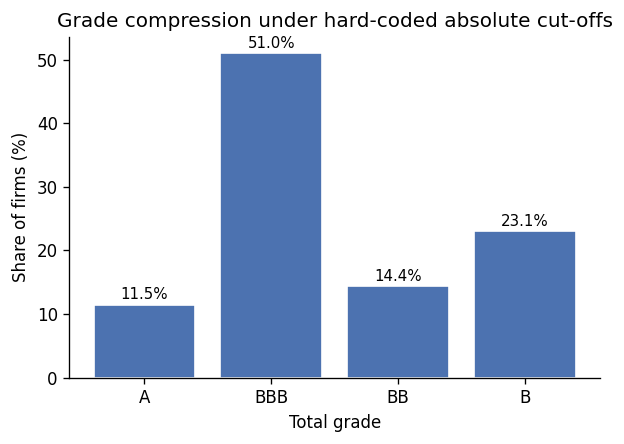

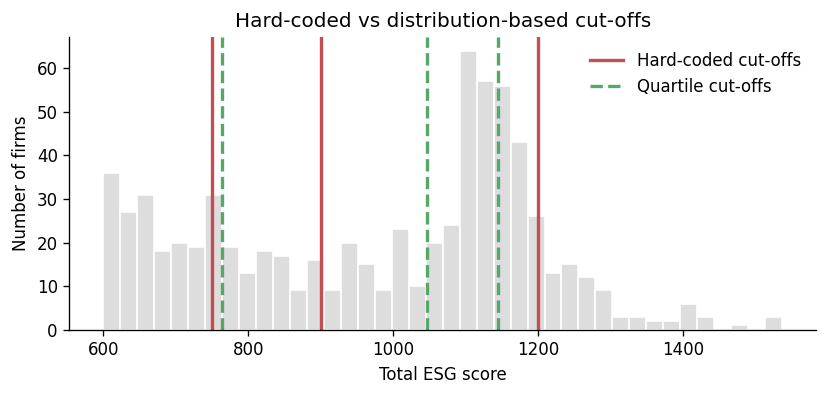


All paper tables (.tex) and figures (.png/.pdf) written to results/. Ready for the manuscript.


In [1]:
# ============================================================
# 03 — Build paper tables (LaTeX) and figures (PNG/PDF)
# Reads results/table/*.csv from notebook 02. Run from notebooks/.
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = os.path.join("..", "data")
TAB_DIR  = os.path.join("..", "results", "table")
FIG_DIR  = os.path.join("..", "results", "figures")
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

def savefig(fig, name):
    """Save both PNG (repo preview) and PDF (LaTeX inclusion)."""
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, name + ".pdf"), bbox_inches="tight")

# ============================================================
# TABLE 1 — Convergent validity (LaTeX, Elsevier booktabs)
# ============================================================
ov = pd.read_csv(os.path.join(TAB_DIR, "convergent_validity_overall.csv"))

def fmt(x):
    return "" if pd.isna(x) else f"{x:.3f}"

lines = [
    r"\begin{table}[t]",
    r"  \centering",
    r"  \caption{Pairwise agreement across three ESG raters "
    r"(Dow~30, direction-aligned).}",
    r"  \label{tab:corr}",
    r"  \begin{tabular}{@{}lS[table-format=-1.3]S[table-format=-1.3]@{}}",
    r"    \toprule",
    r"    Rater pair & {Pearson $r$} & {Spearman $\rho$} \\",
    r"    \midrule",
]
for _, r in ov.iterrows():
    label = r["pair"].replace("&", r"\&")
    sep = r"    \midrule" if r["pair"] == "MEAN" else None
    if sep:
        lines.append(sep)
    lines.append(f"    {label} & {fmt(r['pearson_r'])} "
                 f"& {fmt(r['spearman_rho'])} \\\\")
lines += [r"    \bottomrule", r"  \end{tabular}", r"\end{table}", ""]
tex1 = "\n".join(lines)
with open(os.path.join(TAB_DIR, "table_convergent_validity.tex"), "w") as f:
    f.write(tex1)
print("Wrote table_convergent_validity.tex\n")
print(tex1)

# ============================================================
# TABLE 2 — Cut-off comparison (LaTeX)
# ============================================================
cs = pd.read_csv(os.path.join(TAB_DIR, "cutoff_summary.csv"))
d = dict(zip(cs["metric"], cs["value"]))
tex2 = f"""\\begin{{table}}[t]
  \\centering
  \\caption{{Hard-coded versus distribution-based grade cut-offs
           (broad dataset, $n={int(d['n_firms'])}$).}}
  \\label{{tab:cutoff}}
  \\begin{{tabular}}{{@{{}}lccc@{{}}}}
    \\toprule
    Cut-off scheme & Lower & Middle & Upper \\\\
    \\midrule
    Hard-coded (observed) & 750 & 900 & 1200 \\\\
    Distribution-based (quartiles) & {d['q25']:.0f} & {d['q50']:.0f} & {d['q75']:.0f} \\\\
    \\bottomrule
  \\end{{tabular}}
\\end{{table}}
"""
with open(os.path.join(TAB_DIR, "table_cutoff.tex"), "w") as f:
    f.write(tex2)
print("\nWrote table_cutoff.tex\n")
print(tex2)

# ============================================================
# TABLE 3 — Weighted kappa (ordinal-aware) as LaTeX
# ============================================================
kp = pd.read_csv(os.path.join(TAB_DIR, "convergent_validity_kappa.csv"))
lines3 = [
    r"\begin{table}[t]",
    r"  \centering",
    r"  \caption{Quadratic-weighted Cohen's $\kappa$ across ESG raters "
    r"(Dow~30, ordinal-aware discretisation).}",
    r"  \label{tab:kappa}",
    r"  \begin{tabular}{@{}lS[table-format=1.3]@{}}",
    r"    \toprule",
    r"    Rater pair & {Weighted $\kappa$} \\",
    r"    \midrule",
]
for _, r in kp.iterrows():
    label = r["pair"].replace("&", r"\&")
    lines3.append(f"    {label} & {r['weighted_kappa']:.3f} \\\\")
lines3 += [r"    \bottomrule", r"  \end{tabular}", r"\end{table}", ""]
tex3 = "\n".join(lines3)
with open(os.path.join(TAB_DIR, "table_kappa.tex"), "w") as f:
    f.write(tex3)
print("Wrote table_kappa.tex\n")
print(tex3)

# ============================================================
# FIGURE 1 — Correlation heatmap (3x3, direction-aligned)
# ============================================================
dow = pd.read_csv(os.path.join(DATA_DIR, "Dow30-DATASET-Q2_2024.csv"))
core = dow[["SNP", "Sustainalytics", "MSCI"]].dropna().copy()
msci_map = {"CCC": 1, "B": 2, "BB": 3, "BBB": 4, "A": 5, "AA": 6, "AAA": 7}
aligned = pd.DataFrame({
    "S&P Global":    core["SNP"].values,
    "Sustainalytics": -core["Sustainalytics"].values,   # sign-flip
    "MSCI":          core["MSCI"].map(msci_map).values,
})
C = aligned.corr(method="spearman")

fig, ax = plt.subplots(figsize=(4.6, 4.0))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(C.columns, rotation=30, ha="right")
ax.set_yticks(range(3)); ax.set_yticklabels(C.index)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{C.values[i, j]:.2f}", ha="center", va="center",
                color="black", fontsize=10)
ax.set_title("Cross-rater Spearman correlation\n(direction-aligned, Dow 30)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
savefig(fig, "fig_correlation_heatmap")
plt.show()

# ============================================================
# FIGURE 2 — Grade distribution (compression)
# ============================================================
share = pd.read_csv(os.path.join(TAB_DIR, "cutoff_grade_share.csv"),
                    index_col=0)
share = share.iloc[:, 0]  # first column = share_pct
order = ["A", "BBB", "BB", "B"]
share = share.reindex([g for g in order if g in share.index])

fig, ax = plt.subplots(figsize=(5.2, 3.8))
bars = ax.bar(share.index, share.values, color="#4C72B0", edgecolor="white")
for b, v in zip(bars, share.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}%",
            ha="center", fontsize=9)
ax.set_ylabel("Share of firms (%)")
ax.set_xlabel("Total grade")
ax.set_title("Grade compression under hard-coded absolute cut-offs")
fig.tight_layout()
savefig(fig, "fig_grade_distribution")
plt.show()

# ============================================================
# FIGURE 3 — Hard-coded vs quartile cut-offs on the score axis
# ============================================================
broad = pd.read_csv(os.path.join(DATA_DIR, "data.csv"))
cs = pd.read_csv(os.path.join(TAB_DIR, "cutoff_summary.csv"))
d = dict(zip(cs["metric"], cs["value"]))

fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.hist(broad["total_score"].dropna(), bins=40, color="#DDDDDD",
        edgecolor="white")
for x in [750, 900, 1200]:
    ax.axvline(x, color="#C44E52", lw=2)
for x in [d["q25"], d["q50"], d["q75"]]:
    ax.axvline(x, color="#55A868", lw=2, ls="--")
ax.plot([], [], color="#C44E52", lw=2, label="Hard-coded cut-offs")
ax.plot([], [], color="#55A868", lw=2, ls="--", label="Quartile cut-offs")
ax.set_xlabel("Total ESG score")
ax.set_ylabel("Number of firms")
ax.set_title("Hard-coded vs distribution-based cut-offs")
ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "fig_cutoff_comparison")
plt.show()

print("\nAll paper tables (.tex) and figures (.png/.pdf) written to "
      "results/. Ready for the manuscript.")
